In [ ]:
# Install required libraries
!pip install transformers accelerate matplotlib tqdm

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print(f"Loading {model_name}...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)
print("Model loaded successfully.")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully.


In [3]:
class LlamaHookManager:
    def __init__(self, model):
        self.model = model
        self.hooks = []
        self.activations = {}
        self.gradients = {}
        self.interventions = {}

    def clear(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []
        self.activations = {}
        self.gradients = {}
        self.interventions = {}

    def register_hooks(self):
        self.clear()
        layers = self.model.model.layers
        for i, layer in enumerate(layers):
            def make_hook(layer_idx):
                def hook_fn(module, input, output):
                    # Check if output is a tuple/list or a single Tensor
                    is_tuple = isinstance(output, (tuple, list))
                    h = output[0] if is_tuple else output

                    # Set requires_grad to True so we can compute Jacobians
                    if not h.requires_grad:
                        h = h.clone().requires_grad_(True)
                    self.activations[layer_idx] = h

                    # Register tensor hook to capture gradient during backward pass
                    def backward_hook(grad_output):
                        self.gradients[layer_idx] = grad_output.detach().clone()
                    h.register_hook(backward_hook)

                    # Apply intervention if defined
                    if layer_idx in self.interventions:
                        h_new = self.interventions[layer_idx](h)
                        return (h_new,) + tuple(output[1:]) if is_tuple else h_new

                    return (h,) + tuple(output[1:]) if is_tuple else h
                return hook_fn
            self.hooks.append(layer.register_forward_hook(make_hook(i)))

In [4]:
# Model me se saare stuck hooks clear karne ke liye
for layer in model.model.layers:
    layer._forward_hooks.clear()
print("Stuck hooks cleared successfully!")

Stuck hooks cleared successfully!


In [16]:
class JacobianLens:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.d_model = model.config.hidden_size
        self.num_layers = model.config.num_hidden_layers
        self.J = {}

    def calibrate(self, prompts, num_prompts=20):
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = True

        for l in range(self.num_layers):
            self.J[l] = torch.zeros((self.d_model, self.d_model), device=device, dtype=torch.float32)

        total_tokens = 0
        hook_mgr = LlamaHookManager(self.model)
        hook_mgr.register_hooks()

        prompts = prompts[:num_prompts]
        for prompt in tqdm(prompts, desc="Calibrating J-lens"):
            inputs = self.tokenizer(prompt, return_tensors="pt").to(device)
            input_ids = inputs["input_ids"]
            seq_len = input_ids.size(1)
            if seq_len < 3:
                continue

            hook_mgr.activations.clear()
            hook_mgr.gradients.clear()

            # Forward pass
            outputs = self.model(input_ids)
            h_final = hook_mgr.activations[self.num_layers - 1]

            # Sample Rademacher random variables
            z = torch.randint(0, 2, h_final.shape, device=device, dtype=h_final.dtype) * 2 - 1

            # VJP Loss
            loss = (z * h_final).sum()
            self.model.zero_grad()
            loss.backward()

            # Local VJP: Direct dot-product with same position z (no cross-position noise)
            z_squeezed = z[0] # (seq_len, d_model)
            for l in range(self.num_layers):
                if l in hook_mgr.gradients:
                    g = hook_mgr.gradients[l][0] # (seq_len, d_model)
                    self.J[l] += (z_squeezed.T @ g).float()

            total_tokens += seq_len

        hook_mgr.clear()

        for l in range(self.num_layers):
            self.J[l] /= total_tokens
            self.J[l] = self.J[l].to(self.model.dtype)

        print(f"Calibration completed over {total_tokens} tokens.")

    def decode_activation(self, h, layer_idx):
        J_l = self.J[layer_idx]
        h_lens = torch.matmul(h, J_l.T)
        h_norm = self.model.model.norm(h_lens)
        logits = self.model.lm_head(h_norm)
        return logits

    def get_top_tokens(self, h, layer_idx, k=5):
        logits = self.decode_activation(h, layer_idx)
        probs = F.softmax(logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, k, dim=-1)

        if len(logits.shape) == 1:
            return [(self.tokenizer.decode([idx]).strip(), prob.item()) for idx, prob in zip(top_indices, top_probs)]
        else:
            res = []
            for pos in range(logits.shape[0]):
                res.append([(self.tokenizer.decode([idx]).strip(), prob.item()) for idx, prob in zip(top_indices[pos], top_probs[pos])])
            return res

In [17]:
calibration_texts = [
    "The capital of France is Paris, which is known for its beautiful architecture and landmarks like the Eiffel Tower.",
    "Artificial intelligence and large language models are transforming how we write code and analyze data.",
    "To bake a chocolate cake from scratch, you need to combine flour, sugar, cocoa powder, baking soda, and eggs.",
    "Photosynthesis is a biological process where green plants convert sunlight, water, and carbon dioxide into oxygen and glucose.",
    "Quantum computing uses the principles of superposition and entanglement to perform complex computations faster.",
    "The solar system consists of the Sun and the astronomical objects bound to it by gravity, including the eight planets.",
    "In python programming, you can define a function using the def keyword followed by the function name and arguments.",
    "A standard deck of cards contains fifty-two cards divided into four suits: spades, hearts, diamonds, and clubs.",
    "The Great Barrier Reef is the world's largest coral reef system, located in the Coral Sea off the coast of Australia.",
    "DNA contains the genetic instructions used in the development and functioning of all known living organisms.",
    "The Roman Empire was one of the largest empires in history, stretching across Europe, North Africa, and the Middle East.",
    "Water is a chemical compound consisting of two hydrogen atoms bonded to a single oxygen atom.",
    "The theory of relativity, developed by Albert Einstein, revolutionized our understanding of space, time, and gravity.",
    "An earthquake is the shaking of the surface of the Earth resulting from a sudden release of energy in the lithosphere.",
    "The internet is a global system of interconnected computer networks that link billions of devices worldwide.",
    "Economics is the social science that studies the production, distribution, and consumption of goods and services.",
    "The Amazon rainforest is the largest tropical rainforest in the world and represents over half of the planet's remaining rainforests.",
    "Cell division is the process by which a parent cell divides into two or more daughter cells.",
    "The periodic table organizes all chemical elements by atomic number, electron configuration, and recurring chemical properties.",
    "Newton's laws of motion describe the relationship between a body and the forces acting upon it, and its motion in response."
]

for layer in model.model.layers:
    layer._forward_hooks.clear()

jlens = JacobianLens(model, tokenizer)
jlens.calibrate(calibration_texts, num_prompts=20)

Calibrating J-lens:   0%|          | 0/20 [00:00<?, ?it/s]

Calibration completed over 504 tokens.


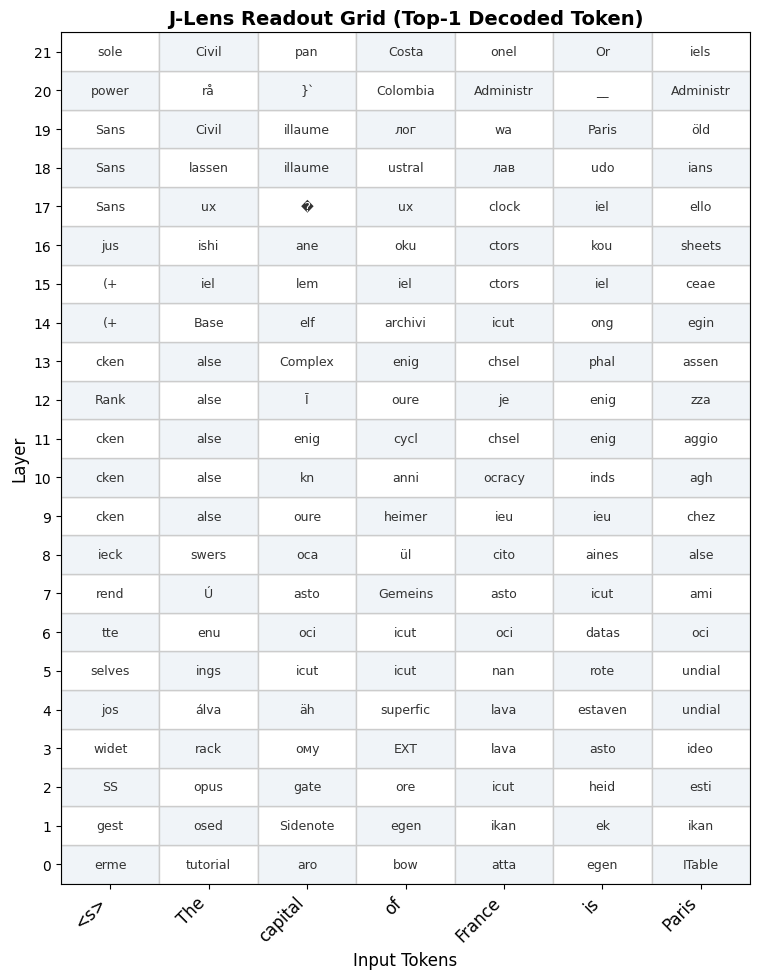

In [10]:
def plot_jlens_grid(prompt):
    # hooks clear karne ke liye safety line
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    seq_len = input_ids.size(1)

    hook_mgr = LlamaHookManager(model)
    hook_mgr.register_hooks()

    with torch.no_grad():
        model(input_ids)

    grid = []
    tokens = [tokenizer.decode([tid]).strip() for tid in input_ids[0]]

    for l in range(jlens.num_layers):
        h_l = hook_mgr.activations[l][0]
        top_tokens_l = jlens.get_top_tokens(h_l, l, k=1)
        grid.append([item[0][0] for item in top_tokens_l])

    hook_mgr.clear()

    # Plotting
    fig, ax = plt.subplots(figsize=(seq_len * 1.1, jlens.num_layers * 0.45))
    ax.set_xlim(-0.5, seq_len - 0.5)
    ax.set_ylim(-0.5, jlens.num_layers - 0.5)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=12)
    ax.set_yticks(range(jlens.num_layers))
    ax.set_ylabel("Layer", fontsize=12)
    ax.set_xlabel("Input Tokens", fontsize=12)
    ax.set_title("J-Lens Readout Grid (Top-1 Decoded Token)", fontsize=14, fontweight='bold')

    for l in range(jlens.num_layers):
        for t in range(seq_len):
            bg_color = "#f0f4f8" if (l + t) % 2 == 0 else "#ffffff"
            rect = plt.Rectangle((t - 0.5, l - 0.5), 1, 1, facecolor=bg_color, edgecolor="#cccccc")
            ax.add_patch(rect)
            ax.text(t, l, grid[l][t], ha="center", va="center", color="#333333", fontsize=9)

    plt.tight_layout()
    plt.show()

# Clean prompt par run karein
plot_jlens_grid("The capital of France is Paris")

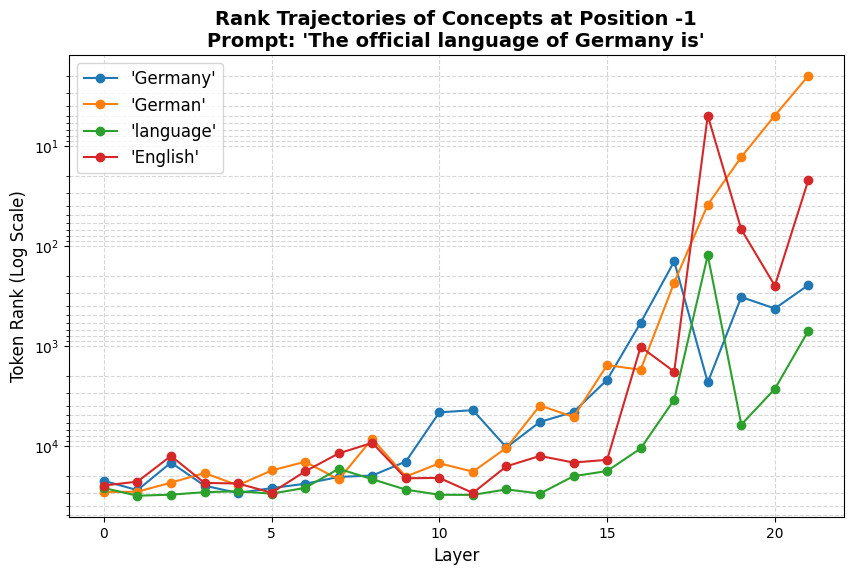

In [11]:
def plot_token_trajectories(prompt, target_tokens, target_pos=-1):
    # hooks clear karne ke liye safety line
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    hook_mgr = LlamaHookManager(model)
    hook_mgr.register_hooks()

    with torch.no_grad():
        model(input_ids)

    ranks = {tok: [] for tok in target_tokens}

    for l in range(jlens.num_layers):
        h_l = hook_mgr.activations[l][0, target_pos]
        logits = jlens.decode_activation(h_l, l)
        probs = F.softmax(logits, dim=-1)
        sorted_indices = torch.argsort(probs, descending=True)

        for tok in target_tokens:
            tok_id = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(tok))
            if len(tok_id) == 0:
                ranks[tok].append(float('nan'))
                continue
            rank = (sorted_indices == tok_id[0]).nonzero()
            if len(rank) > 0:
                ranks[tok].append(rank.item() + 1)
            else:
                ranks[tok].append(float('nan'))

    hook_mgr.clear()

    # Plot
    plt.figure(figsize=(10, 6))
    for tok, r_list in ranks.items():
        plt.plot(range(jlens.num_layers), r_list, marker='o', label=f"'{tok}'")

    plt.yscale("log")
    plt.gca().invert_yaxis() # Rank 1 at the top
    plt.xlabel("Layer", fontsize=12)
    plt.ylabel("Token Rank (Log Scale)", fontsize=12)
    plt.title(f"Rank Trajectories of Concepts at Position {target_pos}\nPrompt: '{prompt}'", fontsize=14, fontweight='bold')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    plt.show()

# Clean prompt par run
plot_token_trajectories(
    prompt="The official language of Germany is",
    target_tokens=["Germany", "German", "language", "English"],
    target_pos=-1
)

In [20]:
def get_token_id(word):
    # Word ke aage space add karein
    ids = tokenizer.encode(" " + word.strip(), add_special_tokens=False)
    # Agar tokenizer ne automatic BOS token (ID 1) add kar diya hai, toh use remove karein
    if len(ids) > 1 and ids[0] == 1:
        return ids[1]
    return ids[0]

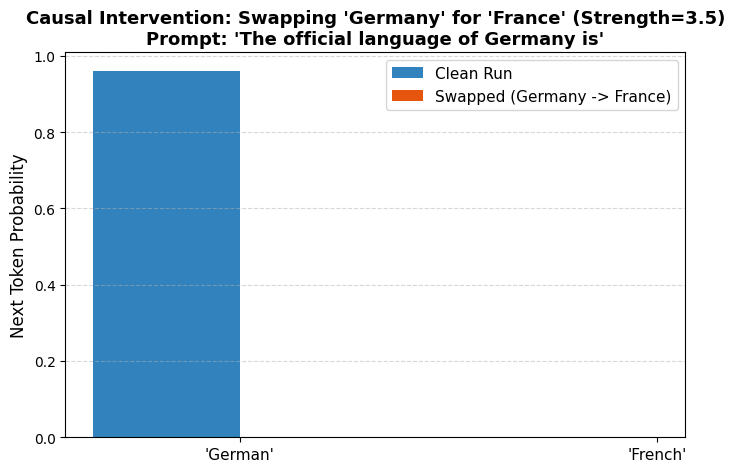

In [21]:
def get_token_id(word):
    # Word ke aage space add karein
    ids = tokenizer.encode(" " + word.strip(), add_special_tokens=False)
    # Agar tokenizer ne automatic BOS token (ID 1) add kar diya hai, toh use remove karein
    if len(ids) > 1 and ids[0] == 1:
        return ids[1]
    return ids[0]

def swap_coordinates_intervention(prompt, token_A_str, token_B_str, swap_layers, output_tokens_to_plot, alpha=3.0):
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    token_A_id = get_token_id(token_A_str)
    token_B_id = get_token_id(token_B_str)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs_clean = model(input_ids)
        probs_clean = F.softmax(outputs_clean.logits[0, -1], dim=-1)

    def make_swap_intervention(l):
        U_A = model.lm_head.weight[token_A_id]
        U_B = model.lm_head.weight[token_B_id]
        v_A = torch.matmul(jlens.J[l].T, U_A)
        v_B = torch.matmul(jlens.J[l].T, U_B)

        def swap_hook(h):
            orig_shape = h.shape
            h_flat = h.view(-1, h.size(-1))
            V = torch.stack([v_A, v_B], dim=1)

            VtV = torch.matmul(V.T, V)
            VtV_f32 = VtV.float()
            VtV_inv_f32 = torch.inverse(VtV_f32 + 1e-5 * torch.eye(2, device=h.device, dtype=torch.float32))
            VtV_inv = VtV_inv_f32.to(h.dtype)

            c = torch.matmul(VtV_inv, torch.matmul(V.T, h_flat.T))
            c_A, c_B = c[0], c[1]

            diff_A = (alpha * c_B - c_A).unsqueeze(1) * v_A.unsqueeze(0)
            diff_B = (alpha * c_A - c_B).unsqueeze(1) * v_B.unsqueeze(0)
            h_new = h_flat + diff_A + diff_B
            return h_new.view(orig_shape)
        return swap_hook

    hook_mgr = LlamaHookManager(model)
    hook_mgr.register_hooks()
    for l in swap_layers:
        hook_mgr.interventions[l] = make_swap_intervention(l)

    with torch.no_grad():
        outputs_swapped = model(input_ids)
        probs_swapped = F.softmax(outputs_swapped.logits[0, -1], dim=-1)

    hook_mgr.clear()

    clean_vals = []
    swapped_vals = []
    for tok in output_tokens_to_plot:
        tok_id = get_token_id(tok)
        clean_vals.append(probs_clean[tok_id].item())
        swapped_vals.append(probs_swapped[tok_id].item())

    x = np.arange(len(output_tokens_to_plot))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, clean_vals, width, label='Clean Run', color='#3182bd')
    plt.bar(x + width/2, swapped_vals, width, label=f'Swapped ({token_A_str} -> {token_B_str})', color='#e6550d')

    plt.ylabel('Next Token Probability', fontsize=12)
    plt.title(f"Causal Intervention: Swapping '{token_A_str}' for '{token_B_str}' (Strength={alpha})\nPrompt: '{prompt}'", fontsize=13, fontweight='bold')
    plt.xticks(x, [f"'{tok}'" for tok in output_tokens_to_plot], fontsize=11)
    plt.legend(fontsize=11)
    plt.grid(axis='y', ls='--', alpha=0.5)
    plt.show()

# Run it
swap_layers = list(range(6, 19))
swap_coordinates_intervention(
    prompt="The official language of Germany is",
    token_A_str="Germany",
    token_B_str="France",
    swap_layers=swap_layers,
    output_tokens_to_plot=["German", "French"],
    alpha=3.5
)

In [28]:
def activation_patch_and_generate(prompt_clean, prompt_patch, token_to_patch_str, swap_layers, max_new_tokens=8):
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    inputs_clean = tokenizer(prompt_clean, return_tensors="pt").to(device)
    inputs_patch = tokenizer(prompt_patch, return_tensors="pt").to(device)

    token_id = get_token_id(token_to_patch_str)
    pos_clean = (inputs_clean["input_ids"][0] == token_id).nonzero(as_tuple=True)[0].tolist()

    if len(pos_clean) == 0:
        print(f"Error: Token '{token_to_patch_str}' not found in clean prompt.")
        return
    pos_idx = pos_clean[0]

    # 1. Clean Run
    with torch.no_grad():
        out_clean = model.generate(**inputs_clean, max_new_tokens=max_new_tokens, do_sample=False)
        clean_text = tokenizer.decode(out_clean[0][inputs_clean["input_ids"].size(1):]).strip()

    # 2. Record activations from the patch prompt (e.g. France)
    patch_activations = {}
    hook_mgr_patch = LlamaHookManager(model)
    hook_mgr_patch.register_hooks()

    with torch.no_grad():
        model(**inputs_patch)
        for l in swap_layers:
            patch_activations[l] = hook_mgr_patch.activations[l][0, pos_idx].clone()

    hook_mgr_patch.clear()

    # 3. Patch registered activations into the clean run (replace Spain with France)
    def make_patch_hook(l):
        target_act = patch_activations[l]
        def patch_hook(h):
            if h.size(1) > 1: # Prefill phase
                h_new = h.clone()
                if pos_idx < h.size(1):
                    h_new[0, pos_idx] = target_act
                return h_new
            return h
        return patch_hook

    hook_mgr_clean = LlamaHookManager(model)
    hook_mgr_clean.register_hooks()
    for l in swap_layers:
        hook_mgr_clean.interventions[l] = make_patch_hook(l)

    # 4. Generate with patched activations
    with torch.no_grad():
        out_swapped = model.generate(**inputs_clean, max_new_tokens=max_new_tokens, do_sample=False)
        swapped_text = tokenizer.decode(out_swapped[0][inputs_clean["input_ids"].size(1):]).strip()

    hook_mgr_clean.clear()

    print("=" * 60)
    print(f"CLEAN PROMPT   : {prompt_clean}")
    print(f"PATCH PROMPT   : {prompt_patch}")
    print(f"CLEAN OUTPUT   : {clean_text}")
    print(f"PATCHED OUTPUT : {swapped_text}")
    print("=" * 60 + "\n")

# Mid-to-deep layers (L6 to L18) where reasoning and facts are processed
swap_layers = list(range(6, 19))

# Test 1: Spain -> France (Expected Swapped Output: Paris)
activation_patch_and_generate(
    prompt_clean="The capital of Spain is",
    prompt_patch="The capital of France is",
    token_to_patch_str="Spain",
    swap_layers=swap_layers
)

# Test 2: Spain -> Germany (Expected Swapped Output: German)
activation_patch_and_generate(
    prompt_clean="The language spoken in Spain is",
    prompt_patch="The language spoken in Germany is",
    token_to_patch_str="Spain",
    swap_layers=swap_layers
)

[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


CLEAN PROMPT   : The capital of Spain is
PATCH PROMPT   : The capital of France is
CLEAN OUTPUT   : Madrid.

2. The capital
PATCHED OUTPUT : Paris.

2. B.



[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


CLEAN PROMPT   : The language spoken in Spain is
PATCH PROMPT   : The language spoken in Germany is
CLEAN OUTPUT   : Castilian Spanish, which is a dialect
PATCHED OUTPUT : German.

2. English The



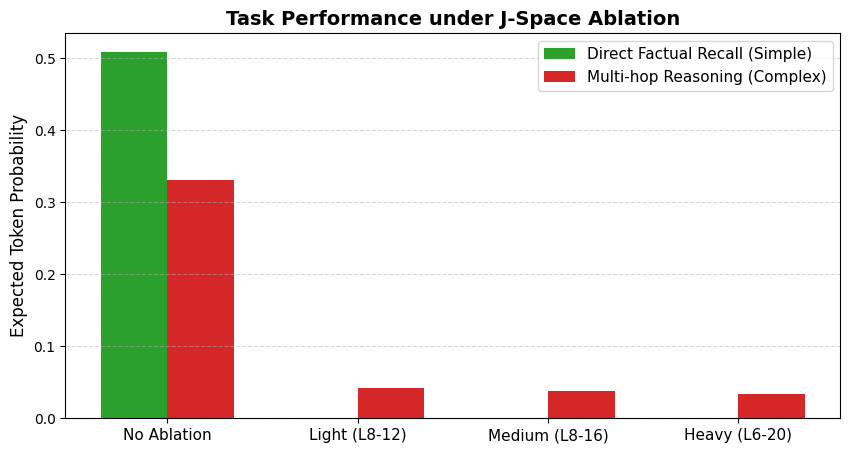

In [29]:
# safety clear for stuck hooks
for layer in model.model.layers:
    layer._forward_hooks.clear()

def ablate_jspace_forward_hook(h, layer_idx, jlens, clean_top_10, k=10):
    orig_shape = h.shape
    h_new = h.clone()
    for b in range(h.size(0)):
        for t in range(h.size(1)):
            h_t = h[b, t]
            logits = jlens.decode_activation(h_t, layer_idx)

            # Exclude top 10 tokens from the final predictions
            exclude_ids = clean_top_10[b, t].tolist()
            masked_logits = logits.clone()
            masked_logits[exclude_ids] = -1e9

            # Get top k J-lens tokens
            _, top_k_indices = torch.topk(masked_logits, k)

            v_list = []
            for idx in top_k_indices.tolist():
                U_j = jlens.model.lm_head.weight[idx]
                v_j = torch.matmul(jlens.J[layer_idx].T, U_j)
                v_list.append(v_j)

            V = torch.stack(v_list, dim=1)

            # Cast to float32 for stable matrix inversion
            VtV = torch.matmul(V.T, V)
            VtV_f32 = VtV.float()
            VtV_inv_f32 = torch.inverse(VtV_f32 + 1e-5 * torch.eye(k, device=h.device, dtype=torch.float32))
            VtV_inv = VtV_inv_f32.to(h.dtype)

            c = torch.matmul(VtV_inv, torch.matmul(V.T, h_t))
            proj = torch.matmul(V, c)

            h_new[b, t] = h_t - proj
    return h_new

def run_task_under_ablation(prompt, expected_token_str, ablation_layers=None, k=10):
    # clear hooks for safety
    for layer in model.model.layers:
        layer._forward_hooks.clear()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    # Use updated get_token_id for correct single token identification
    expected_id = get_token_id(expected_token_str)

    # 1. Clean run to get predictions to exclude
    with torch.no_grad():
        outputs_clean = model(input_ids)
        probs_clean = F.softmax(outputs_clean.logits[0, -1], dim=-1)
        clean_prob = probs_clean[expected_id].item()

        # Get top-10 output tokens at each position
        _, clean_top_10 = torch.topk(F.softmax(outputs_clean.logits, dim=-1), 10, dim=-1)

    if ablation_layers is None or len(ablation_layers) == 0:
        return clean_prob

    # 2. Ablation run
    hook_mgr = LlamaHookManager(model)
    hook_mgr.register_hooks()

    # Set intervention functions for the specified layers
    for l in ablation_layers:
        def make_ablation_hook(layer_idx):
            return lambda h: ablate_jspace_forward_hook(h, layer_idx, jlens, clean_top_10, k=k)
        hook_mgr.interventions[l] = make_ablation_hook(l)

    with torch.no_grad():
        outputs_ablation = model(input_ids)
        probs_ablation = F.softmax(outputs_ablation.logits[0, -1], dim=-1)
        ablation_prob = probs_ablation[expected_id].item()

    hook_mgr.clear()
    return ablation_prob

# Tasks comparison
simple_prompt = "The capital of France is"
simple_target = "Paris"

complex_prompt = "The animal that spins webs has a body with legs numbering"
complex_target = "8"

# Ablation strengths
strengths = {
    "No Ablation": [],
    "Light (L8-12)": list(range(8, 13)),
    "Medium (L8-16)": list(range(8, 17)),
    "Heavy (L6-20)": list(range(6, 21))
}

results_simple = {}
results_complex = {}

for name, layers in strengths.items():
    results_simple[name] = run_task_under_ablation(simple_prompt, simple_target, layers)
    results_complex[name] = run_task_under_ablation(complex_prompt, complex_target, layers)

# Plotting the comparison
plt.figure(figsize=(10, 5))
x = np.arange(len(strengths))
width = 0.35

plt.bar(x - width/2, list(results_simple.values()), width, label='Direct Factual Recall (Simple)', color='#2ca02c')
plt.bar(x + width/2, list(results_complex.values()), width, label='Multi-hop Reasoning (Complex)', color='#d62728')

plt.ylabel('Expected Token Probability', fontsize=12)
plt.title('Task Performance under J-Space Ablation', fontsize=14, fontweight='bold')
plt.xticks(x, list(strengths.keys()), fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', ls='--', alpha=0.5)
plt.show()